In [34]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from math import gcd, isqrt
from fractions import Fraction
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# CLASSICAL ALGORITHMS

In [35]:
# Trial division: tests every odd divisor up to √N. O(√N) queries. Returns (p, q, queries).
def classical_trial_division(N):
    if N < 2:
        return None, None, 0
    if N % 2 == 0:
        return 2, N // 2, 1

    queries = 1
    for i in range(3, isqrt(N) + 1, 2):
        queries += 1
        if N % i == 0:
            return i, N // i, queries

    return None, None, queries

In [36]:
# Pollard's rho: probabilistic sub-exponential factoring. O(N^(1/4)) expected. Returns (p, q, queries).
def classical_pollard_rho(N, x0=2, max_iter=10_000_000):
    if N < 2:
        return None, None, 0
    if N % 2 == 0:
        return 2, N // 2, 1

    x, y, d, queries = x0, x0, 1, 0
    f = lambda x: (x * x + 1) % N
    while d == 1:
        x = f(x)
        y = f(f(y))
        d = gcd(abs(x - y), N)
        queries += 1
        if queries >= max_iter:
            return None, None, queries      # give up

    if d == N:
        return None, None, queries          # cycle detected, no factor found

    return d, N // d, queries

# QUANTUM ALGORITHM (Shor)

In [37]:
# Inverse Quantum Fourier Transform on n_count qubits.
def inverse_qft(n_count):
    qc = QuantumCircuit(n_count, name='inv_QFT')

    # Bit-reversal permutation
    for j in range(n_count // 2):
        qc.swap(j, n_count - 1 - j)

    # Hadamard + inverse controlled phase rotations
    for j in range(n_count):
        qc.h(j)
        for k in range(j + 1, n_count):
            qc.cp(-np.pi / 2 ** (k - j), k, j)

    return qc

In [38]:
# QPE circuit for U|y⟩ = |a·y mod N⟩. Returns a QuantumCircuit.
# n_count  : precision qubits (more -> better phase resolution)
# n_target : ⌈log₂ N⌉ qubits for the target register
#
# Modular exponentiation is a diagonal approximation, controlled-X on each
# target bit where a^(2^j) mod N has that bit set. Exact only for eigenstate |1⟩.
def shor_qpe_circuit(N, a, n_count):
    n_target = N.bit_length()
    total = n_count + n_target
    qc = QuantumCircuit(total, n_count, name='Shor_QPE')

    qc.x(n_count)                           # initialise target register to |1⟩
    qc.h(range(n_count))                    # uniform superposition on counting register

    for j in range(n_count):
        exp = pow(a, 2 ** j, N)             # a^(2^j) mod N, classical pre-computation
        for q_tgt in range(n_target):
            if (exp >> q_tgt) & 1:
                qc.cx(j, n_count + q_tgt)

    qc.append(inverse_qft(n_count), range(n_count))
    qc.measure(range(n_count), range(n_count))
    
    return qc

In [39]:
# Converts measurement outcomes to candidate periods r via the continued-fraction algorithm.
def extract_period_candidates(counts, n_count, N):
    top = sorted(counts.items(), key=lambda x: -x[1])[:12]
    candidates = []
    for bitstr, _ in top:
        measured = int(bitstr, 2)
        if measured == 0:
            continue
        
        phase = measured / (2 ** n_count)
        frac  = Fraction(phase).limit_denominator(N)
        r     = frac.denominator
        if r > 1 and r not in candidates:
            candidates.append(r)

    return candidates

In [40]:
# Shor's algorithm on the Aer simulator.
# Returns (p, q, r, circuit_depth, success, elapsed_time).
def shor_factor(N, a, n_count, shots=2000):
    g = gcd(a, N)
    if g > 1:
        return g, N // g, None, 0, True, 0.0

    qc = shor_qpe_circuit(N, a, n_count)
    circuit_depth = qc.depth()

    backend    = AerSimulator()
    transpiled = transpile(qc, backend)

    start   = time.perf_counter()
    counts  = backend.run(transpiled, shots=shots).result().get_counts()
    elapsed = time.perf_counter() - start

    candidates = extract_period_candidates(counts, n_count, N)

    for r in candidates:
        if r % 2 != 0:
            continue
        
        x = pow(a, r // 2, N)
        for guess in [gcd(x - 1, N), gcd(x + 1, N)]:
            if 1 < guess < N:
                return guess, N // guess, r, circuit_depth, True, elapsed

    return None, None, None, circuit_depth, False, elapsed

In [41]:
# Shor's algorithm on real IBM hardware.
#   elapsed_total : submission → completion  (includes queue wait)
#   elapsed_exec  : running → completion     (circuit execution only)
#   top_prob      : fraction of shots on the top outcome  (noise indicator, higher = less noise)
def shor_factor_real(N, a, n_count, shots=2000):
    g = gcd(a, N)
    if g > 1:
        return g, N // g, None, 0, True, 0.0, 0.0, 'trivial', 1.0

    qc = shor_qpe_circuit(N, a, n_count)
    circuit_depth  = qc.depth()
    n_total_qubits = qc.num_qubits

    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=n_total_qubits)
    print(f"  Using backend: {backend.name}  ({n_total_qubits} qubits needed)")

    pm         = generate_preset_pass_manager(backend=backend, optimization_level=1)
    transpiled = pm.run(qc)

    sampler  = Sampler(backend)
    t_submit = time.perf_counter()
    job      = sampler.run([transpiled], shots=shots)

    print(f"  Job ID: {job.job_id()}")
    t_running = None
    t_done    = None
    while True:
        status    = job.status()
        queue_pos = backend.status().pending_jobs
        now       = time.perf_counter()

        if t_running is None and 'RUNNING' in str(status).upper():
            t_running = now

        if queue_pos is not None:
            print(f"  Status: {status} | Queue position: {queue_pos}", end='\r')
        else:
            print(f"  Status: {status}", end='\r')

        if status in ('DONE', 'CANCELLED', 'ERROR'):
            t_done = now
            print()
            break

        time.sleep(10)

    elapsed_total = t_done - t_submit
    elapsed_exec  = t_done - (t_running if t_running is not None else t_submit)

    result = job.result()
    counts = result[0].data.c.get_counts()

    top_prob   = max(counts.values()) / shots if counts else 0.0
    candidates = extract_period_candidates(counts, n_count, N)

    for r in candidates:
        if r % 2 != 0:
            continue
        
        x = pow(a, r // 2, N)
        for guess in [gcd(x - 1, N), gcd(x + 1, N)]:
            if 1 < guess < N:
                return guess, N // guess, r, circuit_depth, True, elapsed_total, elapsed_exec, backend.name, top_prob

    return None, None, None, circuit_depth, False, elapsed_total, elapsed_exec, backend.name, top_prob

# RUN COMPARISON

In [42]:
# Configurable parameters
# List of (N, a) pairs to benchmark. Each N must be a semiprime (product of two primes) 
# and a must satisfy 1 < a < N  with gcd(a, N) = 1.
BENCHMARK_CASES = [
    (15,  7),   # 15  = 3 × 5
    (21,  2),   # 21  = 3 × 7
    (33,  2),   # 33  = 3 × 11
    (35,  2),   # 35  = 5 × 7
    (77,  2),   # 77  = 7 × 11
    (91,  2),   # 91  = 7 × 13
    (143, 2),   # 143 = 11 × 13
    (221, 2),   # 221 = 13 × 17
]
N_COUNT_MULTIPLIER = 2      # n_count = N_COUNT_MULTIPLIER * ceil(log2(N))
SHOTS              = 2000   # QPE shots per main run
RUNS               = 5      # Repeat classical algorithms this many times and average

# Real hardware is only run for small N to keep circuit depth manageable.
# n_count + n_target total qubits needed:
#   N = 15 ->  8 + 4 = 12 qubits   N = 21 -> 10 + 5 = 15 qubits
#   N = 33 -> 12 + 6 = 18 qubits   N = 35 -> 12 + 6 = 18 qubits
REAL_MAX_N = 35   # run real hardware for cases where N <= REAL_MAX_N

# For Plot 3 (success rate vs n_count): N = 33 is used because the main benchmark
# shows the simulation FAILS at n_count=12 (the standard 2·⌈log₂N⌉).
# ord_33(2) = 10; factoring succeeds only via sub-periods r = 2, 4, 6, 8, which require
# QPE measurements near simple binary fractions (1/2, 1/4, …).
# Sweeping n_count reveals whether the simplified circuit can achieve this at any precision.
SUCCESS_N          = 33
SUCCESS_A          = 2
SUCCESS_N_COUNTS   = list(range(4, 21))     # wider range than default 2·log₂N
SUCCESS_TRIALS     = 50                     # independent runs per n_count value

results = {
    'N':                       [],
    'n_bits':                  [],
    'n_count':                 [],
    'trial_queries':           [],
    'pollard_queries':         [],
    'shor_depth':              [],
    'trial_time':              [],
    'pollard_time':            [],
    'shor_time':               [],
    'shor_correct':            [],
    'shor_real_time_total':    [],   # queue wait + circuit execution
    'shor_real_time_exec':     [],   # circuit execution only (no queue wait)
    'shor_real_correct':       [],
    'shor_real_top_prob':      [],   # fraction of shots on the top outcome (noise indicator)
    'shor_real_ran':           [],   # True if this case was run on real hardware
}

for N, a in BENCHMARK_CASES:
    n_bits   = N.bit_length()
    n_count  = N_COUNT_MULTIPLIER * n_bits

    print(f"N={N}  (bits={n_bits})  a={a}  n_count={n_count}")

    # Trial division
    td_queries_total = 0
    td_time_total    = 0.0
    for _ in range(RUNS):
        start = time.perf_counter()
        _, _, q = classical_trial_division(N)
        td_time_total    += time.perf_counter() - start
        td_queries_total += q

    # Pollard's rho
    pr_queries_total = 0
    pr_time_total    = 0.0
    for _ in range(RUNS):
        x0 = random.randint(2, N - 1)
        start = time.perf_counter()
        _, _, q = classical_pollard_rho(N, x0=x0)
        pr_time_total    += time.perf_counter() - start
        pr_queries_total += q

    # Shor (simulated)
    p, q_fac, r, depth, correct, g_time = shor_factor(N, a, n_count, shots=SHOTS)
    if correct:
        print(f"  Shor (sim)  found: {N} = {p} x {q_fac}  (r={r}, depth={depth})")
    else:
        print(f"  Shor (sim)  did NOT find factors (depth={depth})")

    # Shor (real IBM hardware)
    if N <= REAL_MAX_N:
        p_r, q_r, r_r, _, correct_r, g_time_total, g_time_exec, hw_name, top_prob_r = \
            shor_factor_real(N, a, n_count, shots=SHOTS)
        if correct_r:
            print(f"  Shor (real) found: {N} = {p_r} x {q_r}  (r={r_r}, backend={hw_name})")
        else:
            print(f"  Shor (real) did NOT find factors (backend={hw_name})")
        results['shor_real_time_total'].append(g_time_total)
        results['shor_real_time_exec'].append(g_time_exec)
        results['shor_real_correct'].append(correct_r)
        results['shor_real_top_prob'].append(top_prob_r)
        results['shor_real_ran'].append(True)
    else:
        results['shor_real_time_total'].append(None)
        results['shor_real_time_exec'].append(None)
        results['shor_real_correct'].append(None)
        results['shor_real_top_prob'].append(None)
        results['shor_real_ran'].append(False)

    results['N'].append(N)
    results['n_bits'].append(n_bits)
    results['n_count'].append(n_count)
    results['trial_queries'].append(td_queries_total / RUNS)
    results['pollard_queries'].append(pr_queries_total / RUNS)
    results['shor_depth'].append(depth)
    results['trial_time'].append(td_time_total / RUNS)
    results['pollard_time'].append(pr_time_total / RUNS)
    results['shor_time'].append(g_time)
    results['shor_correct'].append(correct)

# Success-rate sweep (for Plot 3)
print(f"\nSuccess-rate sweep: N={SUCCESS_N}, a={SUCCESS_A}, {SUCCESS_TRIALS} trials each")
success_rates = []
for nc in SUCCESS_N_COUNTS:
    hits = sum(
        shor_factor(SUCCESS_N, SUCCESS_A, nc, shots=SHOTS)[4]
        for _ in range(SUCCESS_TRIALS)
    )
    rate = hits / SUCCESS_TRIALS
    success_rates.append(rate)
    print(f"  n_count={nc:>2}  success={rate:.0%}")

N=15  (bits=4)  a=7  n_count=8
  Shor (sim)  found: 15 = 3 x 5  (r=4, depth=10)
  Using backend: ibm_kingston  (12 qubits needed)
  Job ID: d7gif27b91ec73athsdg
  Status: DONE | Queue position: 0 1
  Shor (real) found: 15 = 3 x 5  (r=4, backend=ibm_kingston)
N=21  (bits=5)  a=2  n_count=10
  Shor (sim)  found: 21 = 3 x 7  (r=2, depth=8)
  Using backend: ibm_kingston  (15 qubits needed)
  Job ID: d7gif6rjne2c7392u76g
  Status: DONE | Queue position: 0 0
  Shor (real) found: 21 = 3 x 7  (r=2, backend=ibm_kingston)
N=33  (bits=6)  a=2  n_count=12
  Shor (sim)  did NOT find factors (depth=14)
  Using backend: ibm_kingston  (18 qubits needed)
  Job ID: d7gifbi2khts739oi3h0
  Status: DONE | Queue position: 0 1
  Shor (real) did NOT find factors (backend=ibm_kingston)
N=35  (bits=6)  a=2  n_count=12
  Shor (sim)  found: 35 = 5 x 7  (r=4, depth=10)
  Using backend: ibm_kingston  (18 qubits needed)
  Job ID: d7gifgc93s0c738rjiag
  Status: DONE | Queue position: 0 0
  Shor (real) found: 35 = 5 x

# PLOT 1 — Queries / Circuit depth

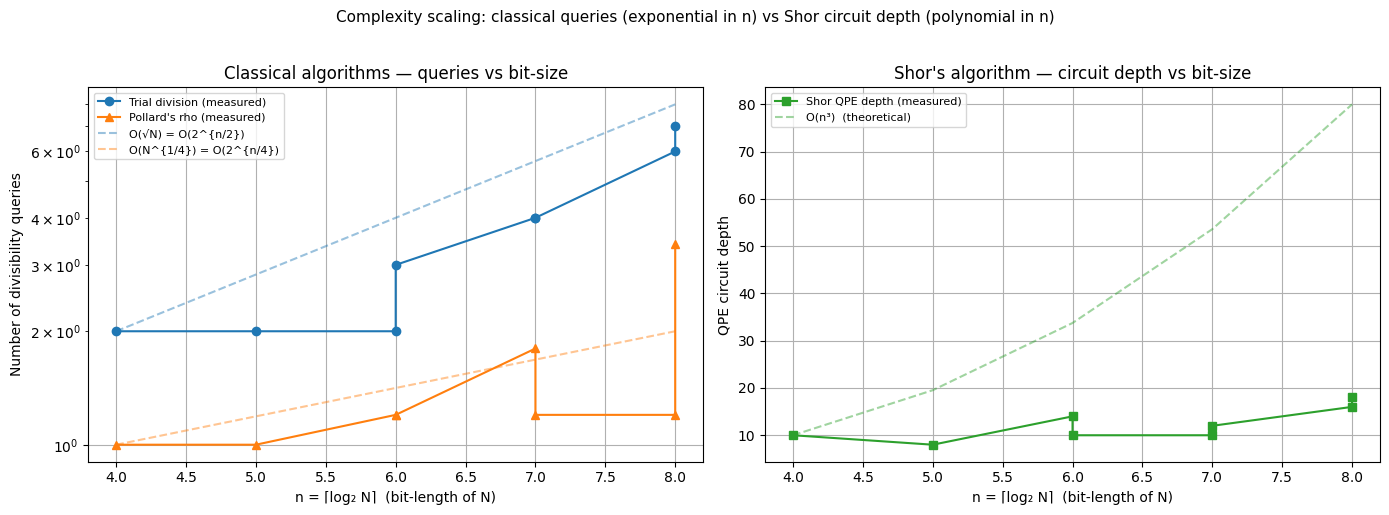

In [43]:
n_bits_arr = np.array(results['n_bits'])
N_arr      = 2.0 ** n_bits_arr

# Theoretical curves normalised to the first data point
def normalise(theory, data):
    return theory * (data[0] / theory[0])

th_trial   = normalise(np.sqrt(N_arr),     np.array(results['trial_queries']))
th_pollard = normalise(N_arr ** 0.25,      np.array(results['pollard_queries']))
th_shor    = normalise(n_bits_arr ** 3,    np.array(results['shor_depth'], dtype=float))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(n_bits_arr, results['trial_queries'],   'o-', color='tab:blue',   label='Trial division (measured)')
ax1.plot(n_bits_arr, results['pollard_queries'], '^-', color='tab:orange', label="Pollard's rho (measured)")
ax1.plot(n_bits_arr, th_trial,   '--', color='tab:blue',   alpha=0.45, label='O(√N) = O(2^{n/2})')
ax1.plot(n_bits_arr, th_pollard, '--', color='tab:orange', alpha=0.45, label='O(N^{1/4}) = O(2^{n/4})')
ax1.set_xlabel('n = ⌈log₂ N⌉  (bit-length of N)')
ax1.set_ylabel('Number of divisibility queries')
ax1.set_title('Classical algorithms — queries vs bit-size')
ax1.set_yscale('log')
ax1.legend(fontsize=8)
ax1.grid(True)

ax2.plot(n_bits_arr, results['shor_depth'], 's-', color='tab:green', label='Shor QPE depth (measured)')
ax2.plot(n_bits_arr, th_shor,              '--', color='tab:green', alpha=0.45, label='O(n³)  (theoretical)')
ax2.set_xlabel('n = ⌈log₂ N⌉  (bit-length of N)')
ax2.set_ylabel('QPE circuit depth')
ax2.set_title("Shor's algorithm — circuit depth vs bit-size")
ax2.legend(fontsize=8)
ax2.grid(True)

fig.suptitle(
    'Complexity scaling: classical queries (exponential in n) vs Shor circuit depth (polynomial in n)',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

# PLOT 2 — Actual execution time

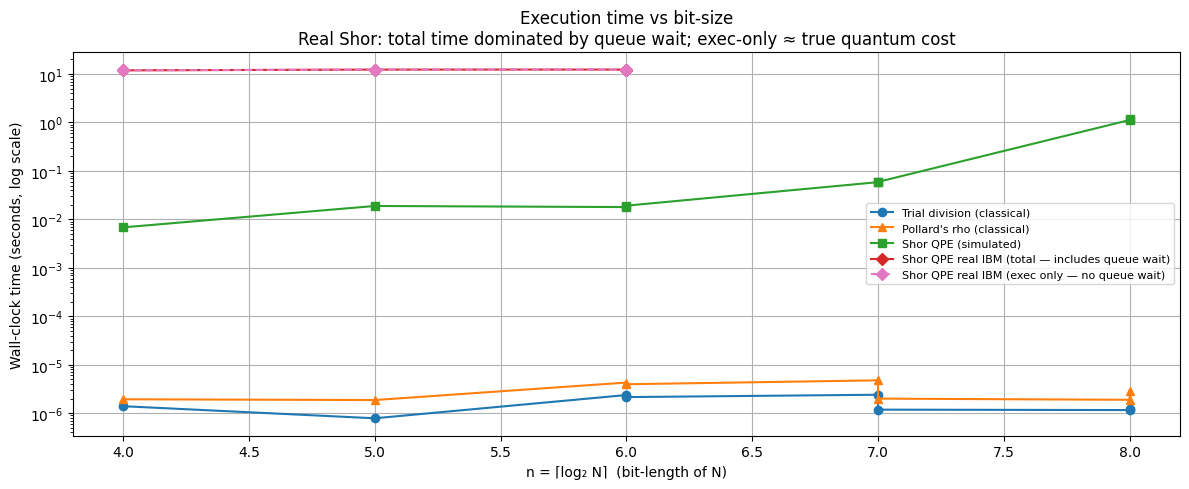

In [44]:
plt.figure(figsize=(12, 5))
plt.plot(n_bits_arr, results['trial_time'],   'o-', color='tab:blue',   label='Trial division (classical)')
plt.plot(n_bits_arr, results['pollard_time'], '^-', color='tab:orange', label="Pollard's rho (classical)")
plt.plot(n_bits_arr, results['shor_time'],    's-', color='tab:green',  label='Shor QPE (simulated)')

real_idx     = [i for i in range(len(results['N'])) if results['shor_real_ran'][i]]
real_n_bits  = [results['n_bits'][i]              for i in real_idx]
real_t_total = [results['shor_real_time_total'][i] for i in real_idx]
real_t_exec  = [results['shor_real_time_exec'][i]  for i in real_idx]

plt.plot(real_n_bits, real_t_total, 'D-',  color='tab:red',  label='Shor QPE real IBM (total — includes queue wait)')
plt.plot(real_n_bits, real_t_exec,  'D--', color='tab:pink', label='Shor QPE real IBM (exec only — no queue wait)')

plt.xlabel('n = ⌈log₂ N⌉  (bit-length of N)')
plt.ylabel('Wall-clock time (seconds, log scale)')
plt.title(
    'Execution time vs bit-size\n'
    'Real Shor: total time dominated by queue wait; exec-only ≈ true quantum cost'
)
plt.yscale('log')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

# PLOT 3 — QPE success rate vs n_count

N=33 is used here because the main benchmark shows the simulation **fails** at n_count=12 (the standard 2·⌈log₂N⌉), making it a more informative test case than N=21 (which always succeeds).

The true period of 2 mod 33 is r=10. The factoring step succeeds via sub-periods r=2,4,6,8 — all of which require the QPE to produce measurements near simple binary fractions (½, ¼, …). Whether the simplified circuit approximation achieves this across different n_count values is what this plot tests.

**Interpreting the result:** if the curve rises with n_count, higher QPE precision helps recover useful phases. If it stays flat near 0%, the bottleneck is the circuit approximation (not QPE precision) — the simplified modular-exponentiation gates do not produce the correct interference pattern for this N regardless of how many counting qubits are used.

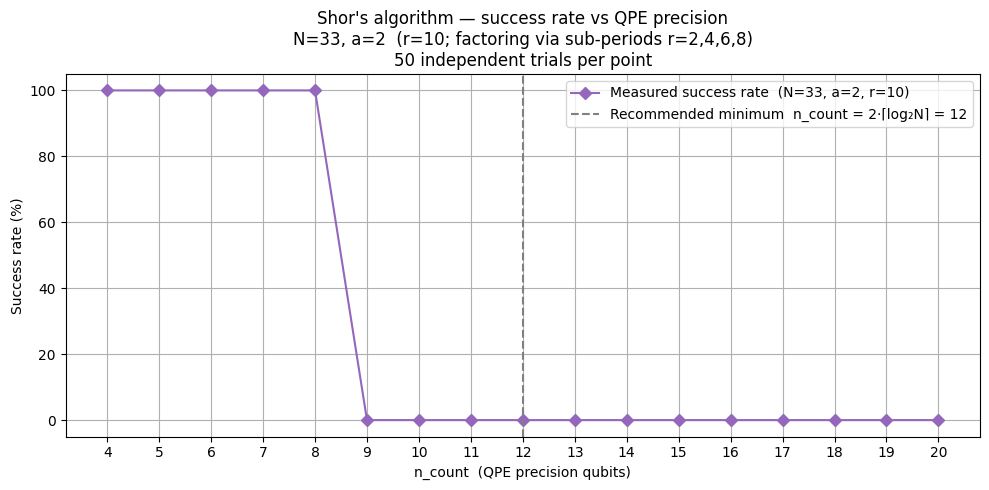

In [45]:
# Success rate vs QPE precision qubits (N = 33, a = 2, ord_33(2) = 10) 
# Sub-periods r = 2, 4, 6, 8 all yield factor 3.  Factoring succeeds if QPE measures a phase near k/r_sub for any of those sub-periods.
# The vertical dashed line marks the recommended minimum 2·⌈log₂N⌉.

n_min_theory = 2 * SUCCESS_N.bit_length()

plt.figure(figsize=(10, 5))
plt.plot(SUCCESS_N_COUNTS, [r * 100 for r in success_rates],
         'D-', color='tab:purple',
         label=f'Measured success rate  (N={SUCCESS_N}, a={SUCCESS_A}, r=10)')
plt.axvline(n_min_theory, color='gray', linestyle='--',
            label=f'Recommended minimum  n_count = 2·⌈log₂N⌉ = {n_min_theory}')
plt.xlabel('n_count  (QPE precision qubits)')
plt.ylabel('Success rate (%)')
plt.title(
    f"Shor's algorithm — success rate vs QPE precision\n"
    f"N={SUCCESS_N}, a={SUCCESS_A}  (r=10; factoring via sub-periods r=2,4,6,8)\n"
    f"{SUCCESS_TRIALS} independent trials per point"
)
plt.ylim(-5, 105)
plt.xticks(SUCCESS_N_COUNTS)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PRINT SUMMARY

In [47]:
header = (
    f"{'N':>6} {'bits':>5} {'n_count':>8} {'Trial Q':>9} {'Pollard Q':>10} "
    f"{'QPE depth':>10} {'Sim OK':>7} {'Real total':>11} {'Real exec':>10} {'Real OK':>8} {'Top prob':>9}"
)
print(header)
print("-" * len(header))
for i in range(len(results['N'])):
    ran      = results['shor_real_ran'][i]
    t_total  = f"{results['shor_real_time_total'][i]:.2f}s" if ran else 'N/A'
    t_exec   = f"{results['shor_real_time_exec'][i]:.2f}s"  if ran else 'N/A'
    real_ok  = 'Yes' if results['shor_real_correct'][i] else ('No' if ran else 'N/A')
    top_prob = f"{results['shor_real_top_prob'][i]:.1%}" if ran else 'N/A'
    print(
        f"{results['N'][i]:>6} "
        f"{results['n_bits'][i]:>5} "
        f"{results['n_count'][i]:>8} "
        f"{results['trial_queries'][i]:>9.1f} "
        f"{results['pollard_queries'][i]:>10.1f} "
        f"{results['shor_depth'][i]:>10} "
        f"{'Yes' if results['shor_correct'][i] else 'No':>7} "
        f"{t_total:>11} "
        f"{t_exec:>10} "
        f"{real_ok:>8} "
        f"{top_prob:>9}"
    )

print(f"\nSuccess-rate sweep  (N={SUCCESS_N}, a={SUCCESS_A}, r=10, {SUCCESS_TRIALS} trials each):")
print(f"  {'n_count':>8}  {'success':>8}")
print("  " + "-" * 19)
for nc, rate in zip(SUCCESS_N_COUNTS, success_rates):
    marker = '  <- recommended minimum' if nc == 2 * SUCCESS_N.bit_length() else ''
    print(f"  {nc:>8}  {rate:>7.0%}{marker}")

     N  bits  n_count   Trial Q  Pollard Q  QPE depth  Sim OK  Real total  Real exec  Real OK  Top prob
-------------------------------------------------------------------------------------------------------
    15     4        8       2.0        1.0         10     Yes      11.92s     11.92s      Yes      6.7%
    21     5       10       2.0        1.0          8     Yes      12.36s     12.36s      Yes      3.1%
    33     6       12       2.0        1.2         14      No      12.37s     12.37s       No      0.2%
    35     6       12       3.0        1.2         10     Yes      12.26s     12.26s      Yes      0.7%
    77     7       14       4.0        1.8         10      No         N/A        N/A      N/A       N/A
    91     7       14       4.0        1.2         12     Yes         N/A        N/A      N/A       N/A
   143     8       16       6.0        1.2         16     Yes         N/A        N/A      N/A       N/A
   221     8       16       7.0        3.4         18     Yes   